# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

We can use the differentialabundance pipeline from day01 for this task.

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [8]:
import pandas as pd

df_contrast = pd.read_csv("./data/contrasts.csv")
df_expression = pd.read_csv("./data/salmon.merged.gene_counts.tsv", sep="\t")

samples = [c for c in df_expression.columns if c not in ("gene_id", "gene_name")]

split = [s.rsplit("_", 1) for s in samples]

df_diff_abund = pd.DataFrame(
    {
        "sample": samples,
        "Condition": [s[0] for s in split],
        "replicate": [int(s[1]) for s in split],
    }
)

df_diff_abund.to_csv("samplesheet_diff_abund.csv", index=False)


Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [ ]:
nextflow run nf-core/differentialabundance \
    -profile rnaseq,docker \
    --input "samplesheet_diff_abund.csv" \
    --contrasts "./data/contrasts.csv"\
    --matrix "./data/salmon.merged.gene_counts.tsv" \
    --feature_length_matrix "./data/rnaseq-out-small/star_salmon/salmon.merged.gene_lengths.tsv" \
    -c nextflow.config \
    --outdir results \
    -resume



Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

for the input I used the sample sheet I produced with the python code above from the gene_counts matrix. This matrix is also used as an input to give the gen count for the statistics and additionally the fetature_length_matrix is alaso added to give the pipeline the gene lengths for each gene count. -c for the able to use memory and cpus. -contrasts for describing sample contrasts to compare groups. 
I changed the number of constrasts to the 3 as in the paper, to get similar results.

What were the outputs of the pipeline?

As an output we got the report file with different analysis, some differnt plots including PCA and volcano, a folder with the tables were we get the different infos per contrast we implemented. 

In [2]:
#!TODO

Would you exclude any samples? If yes, which and why?

SNI_Sal_4 and SNI_Sal_2 could be excluded, because they show ah lot different expression in the PCA plot and also for the Cdr1 expression and also for all other top expressed genes those are the outliners. But this should also be tested significantly if those could be confirmed as outliners.

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

I had 3 contrasts and had the different expressed genes for the 
Sham_oxy vs Sham_sal - 7 up, 0 down
SNI_oxy vs Sham_sal - 1 up, 0 down
SNI_sal vs Sham_sal - 77 up, 2 down

The paper cites multiple hundered gene s overexpressed per region, which does not fit to our analysis.

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

The nucleus accumbens (NAc): part of the ventral striatum in the basal forebrain. It is a central hub of the brain's reward circuit. It integrates dopaminergic and cortical input to influence motivation, reinforcement, and the emotional aspects of pain and opioid reward.

The medial prefrontal cortex (mPFC): A region of the frontal cortex involved in executive functions, such as decision-making, attention, and emotion regulation.

The ventral tegmental area (VTA) is: A midbrain region that contains most of the dopamine neurons in the mesolimbic and mesocortical pathways. It sends dopaminergic projections to the NAc and mPFC.

Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

Yes, they have a bar diagramm with the p-values how significant different genes are for those regions.

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

No, just the list of differnt expressed genes is not sufficient, they still need to be statistcly analysed for a better understanding. 
The paper used different plots to compare the genes with Venn diagrams and heatmaps and also ran Gene Ontology and Ingenuity Pathway Analysis. They also did furhter analysis downsteram to check for inhibitors which could help with the secondary effects of the oxy withdrawl.

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

SNI-oxy vs sham-sal 1
Sham-oxy vs sham-sal 25
SNI-sal vs sham-sal 131


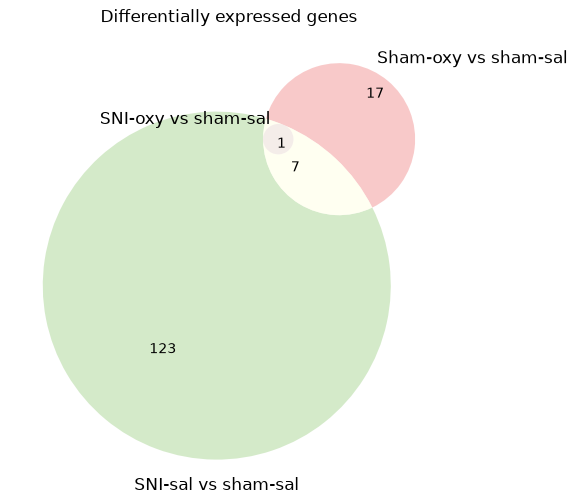

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

base = "results/tables/differential/rnaseq/"
files = {
    "SNI-oxy vs sham-sal":  base + "condition_control_treated_study.deseq2.results.tsv",
    "Sham-oxy vs sham-sal": base + "condition_control_treated_test_study.deseq2.results.tsv",
    "SNI-sal vs sham-sal":  base + "condition_control_treated_sal_study.deseq2.results.tsv",
}

P_CUTOFF, LFC_CUTOFF = 0.05, 0.5

sets = {}
for label, path in files.items():
    df = pd.read_csv(path, sep="\t")
    sig = df[(df["pvalue"] < P_CUTOFF) & (df["log2FoldChange"].abs() > LFC_CUTOFF)]
    sets[label] = set(sig["gene_id"])
    print(label, len(sets[label]))

labels = list(sets)
fig, ax = plt.subplots(figsize=(7, 6))
venn3([sets[l] for l in labels], set_labels=labels,
      set_colors=("#a6b1d8", "#f4a6a6", "#b8dca6"), alpha=0.6, ax=ax)
plt.title("Differentially expressed genes")
plt.savefig("venn_degs.png", dpi=300, bbox_inches="tight")
plt.show()